# Hotel CCTV Privacy System
## RQ1: Selective Face Anonymization | RQ2: Zone-Based Adaptive Differential Privacy

This notebook implements:
- **RQ1**: YOLOv8 face detection + dlib staff recognition + Gaussian blur/pixelation anonymization with benchmarking
- **RQ2**: Zone-based adaptive anonymization using IdentityDP-style differential privacy with epsilon tuning

### Pipeline Overview
```
Video Input → YOLOv8 Face Detection → dlib Staff Recognition
                    ↓                          ↓
            Non-target face              Staff face (no change)
                    ↓
    RQ1: Gaussian Blur / Pixelation
    RQ2: Zone-based ε-DP Noise
                    ↓
            Output Video + Metrics
```

## 1. Install Dependencies

In [ ]:
# Install required packages
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'ipywidgets', '-q'])
packages = [
    'ultralytics',      
    'dlib',             
    'face_recognition', 
    'Pillow',
    'tqdm',
    'scikit-image',     
    'pandas',
    'seaborn',
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

print("Dependencies installed")

✅ Dependencies installed


## 2. Imports & Configuration

In [5]:
import cv2
import numpy as np
import os
import time
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from enum import Enum

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from scipy import stats
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

try:
    from ultralytics import YOLO
    YOLO_AVAILABLE = True
    print("YOLOv8 available")
except ImportError:
    YOLO_AVAILABLE = False
    print("YOLOv8 not available,using OpenCV Haar fallback")

try:
    import face_recognition
    FACE_REC_AVAILABLE = True
    print("face_recognition (dlib) available")
except ImportError:
    FACE_REC_AVAILABLE = False
    print("face_recognition not available — staff recognition disabled")

print("\n all imports complete")

YOLOv8 available
face_recognition (dlib) available

 all imports complete


In [6]:

CONFIG = {
    'wisenet_root': 'sets/',       
    'zone_sets': {
    'lobby':     'set_5',        
    'reception': 'set_3',         
    'corridor':  'set_8',
},
'max_frames': 300,       
    'output_dir': 'output/',                
    'staff_faces_dir': 'staff_faces/',      
    'staff_embeddings_file': 'staff_embeddings.pkl',  

    # Detection
    'yolo_model': 'yolov8n-face.pt',        
    'detection_confidence': 0.45,
    'recognition_tolerance': 0.5,          

    # Anonymization
    'gaussian_kernel': 51,                  
    'gaussian_sigma': 15,
    'pixelation_block': 12,                 

    
    'zones': {
        'lobby':     {'bbox': (0.0, 0.0, 0.5, 1.0), 'type': 'public',  'epsilon': 5.0},
        'reception': {'bbox': (0.5, 0.0, 0.75, 1.0), 'type': 'semi',   'epsilon': 1.0},
        'corridor':  {'bbox': (0.75, 0.0, 1.0, 1.0), 'type': 'private', 'epsilon': 0.1},
    },
    'dp_sensitivity': 1.0,                  


    'benchmarks': ['blur', 'pixelation', 'zone_dp', 'no_anon'],


    'max_frames': None,                     
    'display_preview': True,               
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(CONFIG['staff_faces_dir'], exist_ok=True)
print("Configuration loaded")
print(f"   WiseNET root : {CONFIG['wisenet_root']}")
print(f"   Zone sets    : {CONFIG['zone_sets']}")
print(f"   Output dir  : {CONFIG['output_dir']}")
print(f"   Staff faces : {CONFIG['staff_faces_dir']}")

Configuration loaded
   WiseNET root : sets/
   Zone sets    : {'lobby': 'set_5', 'reception': 'set_3', 'corridor': 'set_8'}
   Output dir  : output/
   Staff faces : staff_faces/


## 3. Face Detector (YOLOv8 + OpenCV fallback)

In [7]:
class FaceDetector:
    

    def __init__(self, model_path: str, conf: float = 0.45):
        self.conf = conf
        self.backend = None

        if YOLO_AVAILABLE:
            try:
                self.model = YOLO(model_path)
                self.model.to('cuda')
                self.backend = 'yolo'
                print(f"YOLOv8 detector loaded: {model_path}")
            except Exception as e:
                print(f"YOLOv8 load failed ({e}) — falling back to Haar")

        if self.backend is None:
            cascade = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
            self.model = cv2.CascadeClassifier(cascade)
            self.backend = 'haar'
            print("Haar cascade detector loaded (fallback)")

    def detect(self, frame: np.ndarray) -> List[Tuple[int,int,int,int]]:
        if self.backend == 'yolo':
            results = self.model(frame, conf=self.conf, verbose=False)[0]
            boxes = []
            if results.boxes is not None:
                for box in results.boxes.xyxy.cpu().numpy():
                    x1, y1, x2, y2 = map(int, box[:4])
                    boxes.append((x1, y1, x2, y2))
            return boxes
        else:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = self.model.detectMultiScale(gray, 1.1, 5, minSize=(30,30))
            return [(x, y, x+w, y+h) for (x, y, w, h) in faces] if len(faces) else []


detector = FaceDetector(CONFIG['yolo_model'], CONFIG['detection_confidence'])
print(f"   Backend: {detector.backend}")

YOLOv8 detector loaded: yolov8n-face.pt
   Backend: yolo


## 4. Staff Recognition (dlib Embeddings)

In [8]:
class StaffRecognizer:


    def __init__(self, staff_dir: str, embeddings_file: str, tolerance: float = 0.5):
        self.tolerance = tolerance
        self.known_embeddings = []
        self.known_names = []
        self.enabled = FACE_REC_AVAILABLE

        if not self.enabled:
            print("Staff recognition disabled (face_recognition not installed)")
            return

        
        if os.path.exists(embeddings_file):
            with open(embeddings_file, 'rb') as f:
                data = pickle.load(f)
                self.known_embeddings = data['embeddings']
                self.known_names = data['names']
            print(f"Loaded {len(self.known_names)} staff embeddings from cache")
        else:
            self._encode_staff(staff_dir, embeddings_file)

    def _encode_staff(self, staff_dir: str, embeddings_file: str):
        """Encode all staff reference images."""
        image_files = list(Path(staff_dir).glob('*.[jpJP][pnPN][gG]*'))
        if not image_files:
            print(f"No staff images found in '{staff_dir}'")
            print("Place one photo per staff member there (filename = staff name)")
            return

        print(f"Encoding {len(image_files)} staff photos...")
        for img_path in tqdm(image_files):
            img = face_recognition.load_image_file(str(img_path))
            encs = face_recognition.face_encodings(img)
            if encs:
                self.known_embeddings.append(encs[0])
                self.known_names.append(img_path.stem)
            else:
                print(f"No face found in {img_path.name}")

        with open(embeddings_file, 'wb') as f:
            pickle.dump({'embeddings': self.known_embeddings, 'names': self.known_names}, f)
        print(f"Encoded {len(self.known_names)} staff members, saved to cache")

    def is_staff(self, frame: np.ndarray, box: Tuple[int,int,int,int]) -> Tuple[bool, str]:
        if not self.enabled or not self.known_embeddings:
            return False, ''

        x1, y1, x2, y2 = box
        face_rgb = cv2.cvtColor(frame[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)
        
        h, w = face_rgb.shape[:2]
        encs = face_recognition.face_encodings(face_rgb, known_face_locations=[(0, w, h, 0)])
        if not encs:
            return False, ''

        distances = face_recognition.face_distance(self.known_embeddings, encs[0])
        best_idx = np.argmin(distances)
        if distances[best_idx] <= self.tolerance:
            return True, self.known_names[best_idx]
        return False, ''


recognizer = StaffRecognizer(
    CONFIG['staff_faces_dir'],
    CONFIG['staff_embeddings_file'],
    CONFIG['recognition_tolerance']
)
print(f"   Staff known: {len(recognizer.known_names)}")

Loaded 1 staff embeddings from cache
   Staff known: 1


## 5. Anonymization Methods (RQ1)

In [9]:
class Anonymizer:
    
    def __init__(self, kernel: int = 51, sigma: int = 15, pixel_block: int = 12):
        self.kernel = kernel if kernel % 2 == 1 else kernel + 1
        self.sigma = sigma
        self.pixel_block = pixel_block

    def gaussian_blur(self, face_roi: np.ndarray) -> np.ndarray:
        return cv2.GaussianBlur(face_roi, (self.kernel, self.kernel), self.sigma)

    def pixelate(self, face_roi: np.ndarray) -> np.ndarray:
        h, w = face_roi.shape[:2]
        bw = max(1, w // self.pixel_block)
        bh = max(1, h // self.pixel_block)
        small = cv2.resize(face_roi, (bw, bh), interpolation=cv2.INTER_LINEAR)
        return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

    def two_step(self, face_roi: np.ndarray) -> np.ndarray:
        
        blurred = self.gaussian_blur(face_roi)
        return self.pixelate(blurred)

    def apply(self, frame: np.ndarray, box: Tuple[int,int,int,int],
              method: str = 'two_step') -> np.ndarray:
        
        x1, y1, x2, y2 = box
        h_f, w_f = frame.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w_f, x2), min(h_f, y2)
        if x2 <= x1 or y2 <= y1:
            return frame

        roi = frame[y1:y2, x1:x2].copy()
        if method == 'blur':
            anon = self.gaussian_blur(roi)
        elif method == 'pixelation':
            anon = self.pixelate(roi)
        else:  # default: two_step
            anon = self.two_step(roi)

        frame[y1:y2, x1:x2] = anon
        return frame


anonymizer = Anonymizer(
    kernel=CONFIG['gaussian_kernel'],
    sigma=CONFIG['gaussian_sigma'],
    pixel_block=CONFIG['pixelation_block']
)
print("Anonymizer ready")
print(f"Gaussian kernel={anonymizer.kernel}, sigma={anonymizer.sigma}")
print(f"Pixelation block={anonymizer.pixel_block}")

Anonymizer ready
Gaussian kernel=51, sigma=15
Pixelation block=12


## 6. Zone-Based Differential Privacy (RQ2)

In [10]:
class ZoneManager:
    

    def __init__(self, zones_config: dict):
        self.zones = zones_config

    def get_zone_for_face(self, box: Tuple[int,int,int,int],
                          frame_w: int, frame_h: int) -> Tuple[str, float]:
        
        cx = ((box[0] + box[2]) / 2) / frame_w
        cy = ((box[1] + box[3]) / 2) / frame_h

        for zone_name, zdata in self.zones.items():
            zx1, zy1, zx2, zy2 = zdata['bbox']
            if zx1 <= cx <= zx2 and zy1 <= cy <= zy2:
                return zone_name, zdata['epsilon']
        return 'unknown', 0.1

    def draw_zones(self, frame: np.ndarray, alpha: float = 0.15) -> np.ndarray:
        h, w = frame.shape[:2]
        overlay = frame.copy()
        zone_colors = {'public': (0,200,0), 'semi': (0,165,255), 'private': (0,0,220)}
        for zname, zdata in self.zones.items():
            zx1, zy1, zx2, zy2 = zdata['bbox']
            pt1 = (int(zx1*w), int(zy1*h))
            pt2 = (int(zx2*w), int(zy2*h))
            color = zone_colors.get(zdata['type'], (200,200,200))
            cv2.rectangle(overlay, pt1, pt2, color, -1)
            cv2.putText(overlay, f"{zname} (ε={zdata['epsilon']})",
                        (pt1[0]+5, pt1[1]+25), cv2.FONT_HERSHEY_SIMPLEX,
                        0.55, color, 2)
        return cv2.addWeighted(overlay, alpha, frame, 1-alpha, 0)


class DifferentialPrivacyAnonymizer:

    def __init__(self, sensitivity: float = 1.0):
        self.sensitivity = sensitivity

    def laplace_noise(self, shape: tuple, epsilon: float) -> np.ndarray:
        scale = self.sensitivity / max(epsilon, 1e-6)
        return np.random.laplace(0, scale, shape)

    def apply_dp(self, face_roi: np.ndarray, epsilon: float) -> np.ndarray:
        roi_f = face_roi.astype(np.float32)
        noise = self.laplace_noise(roi_f.shape, epsilon)
        noise_scaled = noise * (255.0 / (1.0 + epsilon))
        noisy = np.clip(roi_f + noise_scaled, 0, 255).astype(np.uint8)
        return noisy

    def apply_to_frame(self, frame: np.ndarray,
                       box: Tuple[int,int,int,int],
                       epsilon: float) -> np.ndarray:
        x1, y1, x2, y2 = [max(0, v) for v in box]
        x2 = min(frame.shape[1], x2)
        y2 = min(frame.shape[0], y2)
        if x2 <= x1 or y2 <= y1:
            return frame
        frame[y1:y2, x1:x2] = self.apply_dp(frame[y1:y2, x1:x2], epsilon)
        return frame


zone_manager = ZoneManager(CONFIG['zones'])
dp_anonymizer = DifferentialPrivacyAnonymizer(CONFIG['dp_sensitivity'])
print("Zone manager and DP anonymizer ready")
for zname, zdata in CONFIG['zones'].items():
    print(f"   Zone '{zname}': type={zdata['type']}, ε={zdata['epsilon']}")

Zone manager and DP anonymizer ready
   Zone 'lobby': type=public, ε=5.0
   Zone 'reception': type=semi, ε=1.0
   Zone 'corridor': type=private, ε=0.1


## 7. Metrics Collection

In [11]:
@dataclass
class FrameMetrics:
    frame_idx: int
    processing_time_ms: float
    faces_detected: int
    staff_detected: int
    guests_anonymized: int
    method: str
    psnr_values: List[float] = field(default_factory=list)   
    ssim_values: List[float] = field(default_factory=list)
    false_positives: int = 0   
    false_negatives: int = 0   
    zone_epsilons: List[float] = field(default_factory=list)


class MetricsCollector:

    def __init__(self):
        self.records: List[FrameMetrics] = []

    def add(self, m: FrameMetrics):
        self.records.append(m)

    def summary(self) -> dict:
        if not self.records:
            return {}
        df = pd.DataFrame([vars(r) for r in self.records])

        total_faces = df['faces_detected'].sum()
        total_guests = df['guests_anonymized'].sum()
        total_fp = df['false_positives'].sum()
        total_fn = df['false_negatives'].sum()

       
        ppr = total_guests / max(total_guests + total_fn, 1)

        staff_total = df['staff_detected'].sum()
        accuracy = staff_total / max(total_faces, 1)

        all_psnr = [v for row in df['psnr_values'] for v in row]
        all_ssim = [v for row in df['ssim_values'] for v in row]

        
        fdr = total_faces / max(len(self.records), 1)

        return {
            'method': df['method'].iloc[0] if not df.empty else 'unknown',
            'total_frames': len(self.records),
            'avg_processing_ms': df['processing_time_ms'].mean(),
            'fps': 1000 / df['processing_time_ms'].mean() if df['processing_time_ms'].mean() > 0 else 0,
            'faces_detected_total': int(total_faces),
            'avg_faces_per_frame': fdr,
            'privacy_protection_rate': ppr,
            'staff_recognition_accuracy': accuracy,
            'false_positive_rate': total_fp / max(total_faces, 1),
            'false_negative_rate': total_fn / max(total_faces, 1),
            'avg_psnr': np.mean(all_psnr) if all_psnr else None,
            'avg_ssim': np.mean(all_ssim) if all_ssim else None,
            'zone_epsilon_usage': [v for row in df['zone_epsilons'] for v in row],
        }

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame([vars(r) for r in self.records])


print("✅ Metrics collector ready")

✅ Metrics collector ready


## 8. Core Processing Pipeline

In [12]:
def process_video(
    video_path: str,
    method: str,
    output_path: str,
    epsilon_mode: str = 'adaptive', 
    show_zones: bool = False,
    max_frames: Optional[int] = None,
) -> MetricsCollector:
    

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if max_frames:
        total = min(total, max_frames)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    collector = MetricsCollector()
    label = f"{method}" + (f"/{epsilon_mode}" if method == 'zone_dp' else "")
    print(f"\n▶ Processing [{label}] → {output_path}")

    
    UNIFORM_LOW  = 0.1
    UNIFORM_HIGH = 10.0

    for frame_idx in tqdm(range(total), desc=label):
        ret, frame = cap.read()
        if not ret:
            break

        t0 = time.perf_counter()
        original_frame = frame.copy()

        boxes = detector.detect(frame)

        staff_count = 0
        guest_count = 0
        fp_count = 0
        fn_count = 0
        psnr_list = []
        ssim_list = []
        epsilons_used = []

        if show_zones and method == 'zone_dp':
            frame = zone_manager.draw_zones(frame)

        for box in boxes:
            x1, y1, x2, y2 = box
            if frame_idx % 5 == 0:
                is_staff_member, staff_name = recognizer.is_staff(original_frame, box)
            else:
                is_staff_member, staff_name = False, ''

            if is_staff_member:
                staff_count += 1
                
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,220,0), 2)
                cv2.putText(frame, f"Staff: {staff_name}", (x1, y1-8),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,220,0), 1)
            else:
                guest_count += 1
                roi_before = original_frame[max(0,y1):min(height,y2),
                                            max(0,x1):min(width,x2)].copy()

                if method == 'no_anon':
                    pass  

                elif method == 'blur':
                    frame = anonymizer.apply(frame, box, method='blur')

                elif method == 'pixelation':
                    frame = anonymizer.apply(frame, box, method='pixelation')

                elif method == 'two_step':
                    frame = anonymizer.apply(frame, box, method='two_step')

                elif method == 'zone_dp':
                    zone_name, zone_eps = zone_manager.get_zone_for_face(box, width, height)

                    if epsilon_mode == 'adaptive':
                        eps = zone_eps
                    elif epsilon_mode == 'low':
                        eps = UNIFORM_LOW
                    elif epsilon_mode == 'high':
                        eps = UNIFORM_HIGH
                    else:
                        eps = None

                    if eps is not None:
                        frame = dp_anonymizer.apply_to_frame(frame, box, eps)
                        epsilons_used.append(eps)

               
                if method not in ('no_anon',) and roi_before.size > 0:
                    roi_after = frame[max(0,y1):min(height,y2),
                                     max(0,x1):min(width,x2)]
                    if roi_before.shape == roi_after.shape and roi_before.size > 0:
                        if frame_idx % 10 == 0:
                            try:
                                p = psnr(roi_before, roi_after, data_range=255)
                                s = ssim(roi_before, roi_after, channel_axis=2, data_range=255)
                                if np.isfinite(p): psnr_list.append(p)
                                if np.isfinite(s): ssim_list.append(s)
                            except Exception:
                                pass

                
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,0,200), 1)

        
        cv2.putText(frame, f"[{label}] F:{frame_idx} | Faces:{len(boxes)} Staff:{staff_count} Guests:{guest_count}",
                    (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)

        t1 = time.perf_counter()
        proc_ms = (t1 - t0) * 1000

        collector.add(FrameMetrics(
            frame_idx=frame_idx,
            processing_time_ms=proc_ms,
            faces_detected=len(boxes),
            staff_detected=staff_count,
            guests_anonymized=guest_count,
            method=label,
            psnr_values=psnr_list,
            ssim_values=ssim_list,
            false_positives=fp_count,
            false_negatives=fn_count,
            zone_epsilons=epsilons_used,
        ))

        writer.write(frame)

    cap.release()
    writer.release()
    print(f" Saved to {output_path}")
    return collector


print("process_video() defined")

process_video() defined


## 9. Run All Benchmarks

In [13]:
from pathlib import Path
from collections import defaultdict

def get_zone_videos(wisenet_root, zone_sets):
    root = Path(wisenet_root)
    zone_videos = {}
    for zone, set_name in zone_sets.items():
        set_path = root / set_name
        if not set_path.exists():
            print(f"Set not found: {set_path}")
            continue
        videos = sorted(list(set_path.glob('*.avi')) +
                        list(set_path.glob('*.mp4')))
        if not videos:
            print(f"No videos in {set_path}")
            continue
        zone_videos[zone] = [str(v) for v in videos]
        eps = CONFIG['zones'][zone]['epsilon']
        print(f"Zone '{zone}' (ε={eps}) → {set_name}: {len(videos)} videos")
    return zone_videos

def merge_collectors(collectors, key):
    merged_collector = MetricsCollector()
    for c in collectors:
        for record in c.records:
            merged_collector.add(record)
    merged = merged_collector.summary()
    merged['method'] = key
    merged['videos_processed'] = len(collectors)
    merged['total_frames'] = sum(len(c.records) for c in collectors)
    return merged

zone_videos = get_zone_videos(CONFIG['wisenet_root'], CONFIG['zone_sets'])
all_results = {}
OUT = CONFIG['output_dir']
MF  = CONFIG['max_frames']

for zone, videos in zone_videos.items():
    for method in ['blur', 'pixelation', 'two_step', 'no_anon']:
        key = f"{zone}/{method}"
        collectors = []
        for vid in videos:
            out_path = os.path.join(OUT, f"{zone}_{method}_{Path(vid).stem}.mp4")
            c = process_video(vid, method, out_path, max_frames=MF)
            collectors.append(c)
        all_results[key] = merge_collectors(collectors, key)
        print(f"RQ1 [{key}] done — {all_results[key]['total_frames']} frames merged")

for zone, videos in zone_videos.items():
    for eps_mode in ['adaptive', 'low', 'high', 'none']:
        key = f"{zone}/dp_{eps_mode}"
        collectors = []
        for vid in videos:
            out_path = os.path.join(OUT, f"{zone}_dp_{eps_mode}_{Path(vid).stem}.mp4")
            c = process_video(vid, 'zone_dp', out_path,
                              epsilon_mode=eps_mode, max_frames=MF)
            collectors.append(c)
        all_results[key] = merge_collectors(collectors, key)
        print(f"RQ2 [{key}] done — {all_results[key]['total_frames']} frames merged")

with open(os.path.join(OUT, 'results_summary.json'), 'w') as f:
    json.dump(all_results, f, indent=2, default=str)
print("\nAll done. Results saved.")

Zone 'lobby' (ε=5.0) → set_5: 5 videos
Zone 'reception' (ε=1.0) → set_3: 5 videos
Zone 'corridor' (ε=0.1) → set_8: 5 videos

▶ Processing [blur] → output/lobby_blur_video5_1.mp4


blur: 100%|██████████| 1000/1000 [01:13<00:00, 13.63it/s]


 Saved to output/lobby_blur_video5_1.mp4

▶ Processing [blur] → output/lobby_blur_video5_2.mp4


blur: 100%|██████████| 1000/1000 [02:06<00:00,  7.89it/s]


 Saved to output/lobby_blur_video5_2.mp4

▶ Processing [blur] → output/lobby_blur_video5_3.mp4


...

 Saved to output/corridor_dp_none_video8_3.mp4

▶ Processing [zone_dp/none] → output/corridor_dp_none_video8_4.mp4


zone_dp/none: 100%|██████████| 1000/1000 [02:51<00:00,  5.82it/s]


 Saved to output/corridor_dp_none_video8_4.mp4

▶ Processing [zone_dp/none] → output/corridor_dp_none_video8_5.mp4


zone_dp/none: 100%|██████████| 1000/1000 [01:07<00:00, 14.74it/s]

 Saved to output/corridor_dp_none_video8_5.mp4
RQ2 [corridor/dp_none] done — 5000 frames merged

All done. Results saved.


## 10. Results & Visualizations

In [18]:

results_file = os.path.join(CONFIG['output_dir'], 'results_summary.json')

if os.path.exists(results_file):
    with open(results_file) as f:
        all_results = json.load(f)
else:
    print("No results yet — run Section 9 first, or load a saved JSON here.")
    all_results = {}

if all_results:
    df = pd.DataFrame(all_results).T
    df = df.reset_index().rename(columns={'index': 'run'})
    for col in ['avg_processing_ms', 'fps', 'privacy_protection_rate',
                'staff_recognition_accuracy', 'false_positive_rate',
                'false_negative_rate', 'avg_psnr', 'avg_ssim']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    print(df[['run','fps','privacy_protection_rate','avg_psnr','avg_ssim']].to_string(index=False))

                  run       fps  privacy_protection_rate  avg_psnr  avg_ssim
           lobby/blur 11.751184                      1.0 20.695969  0.266209
     lobby/pixelation 11.637712                      1.0 19.305073  0.263810
       lobby/two_step 11.577189                      1.0 20.669482  0.262539
        lobby/no_anon 11.605537                      1.0       NaN       NaN
       reception/blur 45.056265                      1.0 19.188707  0.316924
 reception/pixelation 45.884401                      1.0 18.096128  0.305947
   reception/two_step 46.721096                      1.0 19.053859  0.306674
    reception/no_anon 45.244720                      1.0       NaN       NaN
        corridor/blur 14.306245                      1.0 16.487528  0.160321
  corridor/pixelation  3.046690                      1.0 15.106740  0.154576
    corridor/two_step 14.434977                      1.0 16.430974  0.157034
     corridor/no_anon 14.463653                      1.0       NaN       NaN

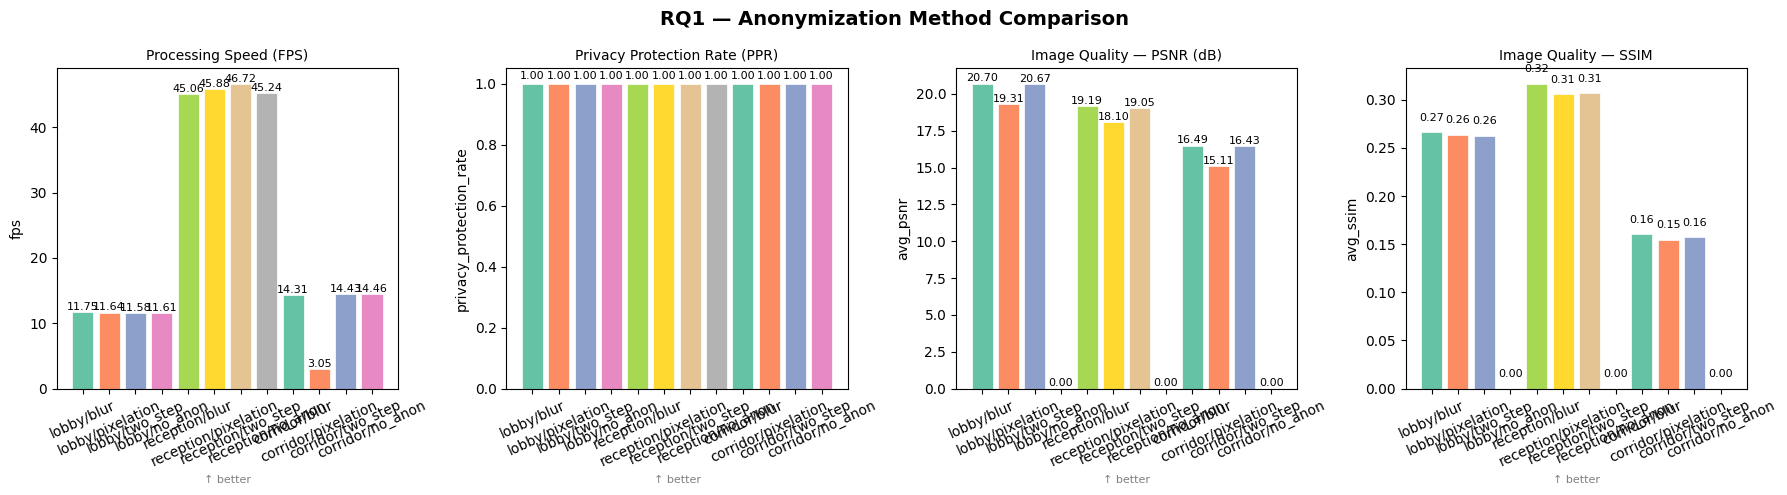

RQ1 chart saved


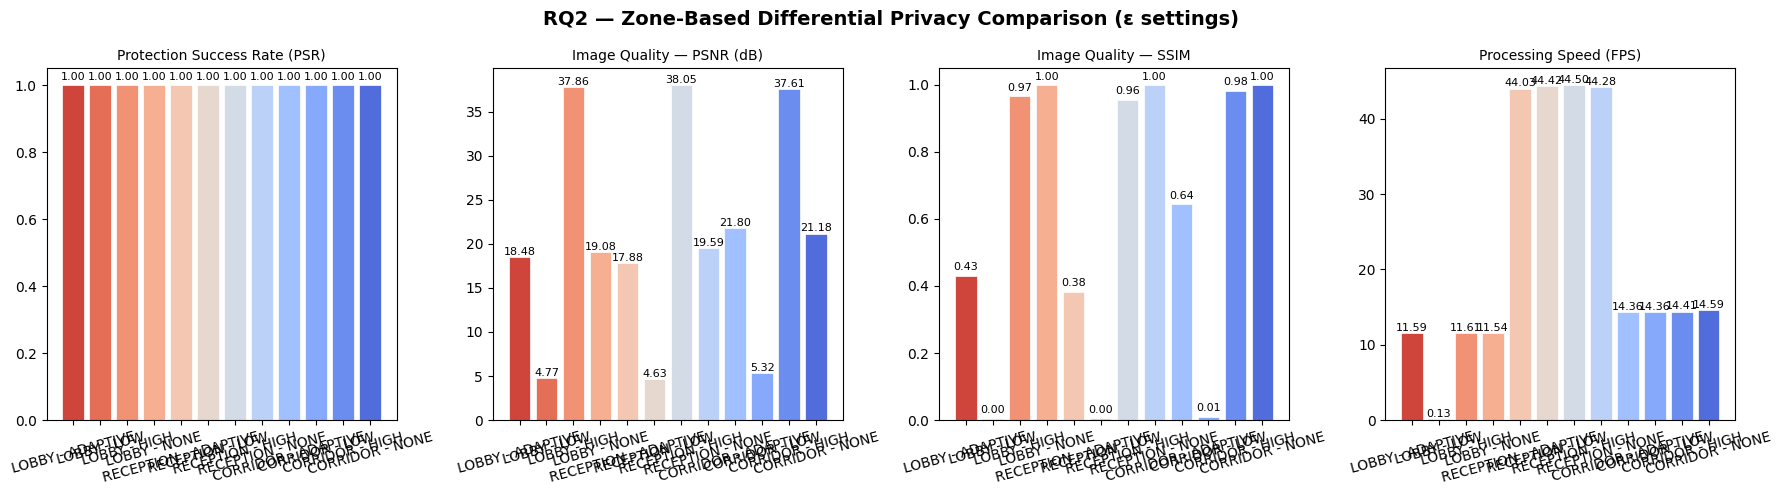

RQ2 chart saved


In [15]:
def plot_rq1_benchmarks(df: pd.DataFrame):
    rq1_methods = ['blur', 'pixelation', 'two_step', 'no_anon']
    rq1 = df[df['run'].str.split('/').str[-1].isin(rq1_methods)].copy()
    if rq1.empty:
        print("No RQ1 data to plot.")
        return

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle('RQ1 — Anonymization Method Comparison', fontsize=14, fontweight='bold')
    palette = sns.color_palette('Set2', len(rq1))

    metrics = [
        ('fps',                      'Processing Speed (FPS)',          True),
        ('privacy_protection_rate',  'Privacy Protection Rate (PPR)',   True),
        ('avg_psnr',                 'Image Quality — PSNR (dB)',       True),
        ('avg_ssim',                 'Image Quality — SSIM',            True),
    ]

    for ax, (metric, title, higher_better) in zip(axes, metrics):
        vals = rq1[metric].fillna(0)
        bars = ax.bar(rq1['run'], vals, color=palette, edgecolor='white', linewidth=0.5)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=25)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        note = '↑ better' if higher_better else '↓ better'
        ax.set_xlabel(note, fontsize=8, color='gray')

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'rq1_benchmarks.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("RQ1 chart saved")


def plot_rq2_dp_comparison(df: pd.DataFrame):
    rq2_modes = ['dp_adaptive', 'dp_low', 'dp_high', 'dp_none']
    rq2 = df[df['run'].str.split('/').str[-1].isin(rq2_modes)].copy()
    if rq2.empty:
        print("No RQ2 data to plot.")
        return

    labels = [r.replace('/dp_', ' - ').upper() for r in rq2['run']]
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle('RQ2 — Zone-Based Differential Privacy Comparison (ε settings)', fontsize=14, fontweight='bold')
    palette = sns.color_palette('coolwarm_r', len(rq2))

    metrics = [
        ('privacy_protection_rate', 'Protection Success Rate (PSR)'),
        ('avg_psnr',                'Image Quality — PSNR (dB)'),
        ('avg_ssim',                'Image Quality — SSIM'),
        ('fps',                     'Processing Speed (FPS)'),
    ]

    for ax, (metric, title) in zip(axes, metrics):
        vals = rq2[metric].fillna(0)
        bars = ax.bar(labels, vals, color=palette, edgecolor='white', linewidth=0.5)
        ax.set_title(title, fontsize=10)
        ax.tick_params(axis='x', rotation=15)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'rq2_dp_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("RQ2 chart saved")


def plot_zone_epsilon_distribution(collector: MetricsCollector):
    df = collector.to_dataframe()
    all_eps = [v for row in df['zone_epsilons'] for v in row]
    if not all_eps:
        print("No epsilon data collected.")
        return
    eps_counts = pd.Series(all_eps).value_counts().sort_index()
    zone_labels = {v['epsilon']: f"{k} (ε={v['epsilon']})" for k, v in CONFIG['zones'].items()}
    fig, ax = plt.subplots(figsize=(7,4))
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    bars = ax.bar([zone_labels.get(e, str(e)) for e in eps_counts.index],
                  eps_counts.values, color=colors[:len(eps_counts)])
    ax.set_title('RQ2 — Zone Epsilon Usage Distribution (Adaptive Mode)', fontweight='bold')
    ax.set_ylabel('Face anonymizations')
    ax.set_xlabel('Zone (ε value)')
    for bar, val in zip(bars, eps_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'rq2_epsilon_distribution.png'), dpi=150)
    plt.show()


if all_results:
    plot_rq1_benchmarks(df)
    plot_rq2_dp_comparison(df)

## 11. Statistical Analysis (ANOVA / Kruskal-Wallis)

In [19]:
def run_statistical_tests(collectors: Dict[str, MetricsCollector]):
    print("=" * 60)
    print("STATISTICAL ANALYSIS")
    print("=" * 60)

    for metric_name, extractor in [
        ('Processing Time (ms)', lambda m: [r.processing_time_ms for r in m.records]),
        ('PSNR',                 lambda m: [v for r in m.records for v in r.psnr_values]),
        ('SSIM',                 lambda m: [v for r in m.records for v in r.ssim_values]),
    ]:
        groups = {k: extractor(v) for k, v in collectors.items()}
        groups = {k: v for k, v in groups.items() if len(v) >= 3}

        if len(groups) < 2:
            print(f"\n{metric_name}: insufficient data")
            continue

        print(f"\n── {metric_name} ──")
        for k, vals in groups.items():
            print(f"   {k:25s}: n={len(vals):4d}  mean={np.mean(vals):.3f}  std={np.std(vals):.3f}")

        sample = list(groups.values())[0][:5000]
        if len(sample) >= 3:
            _, p_norm = stats.shapiro(sample)
        else:
            p_norm = 0

        group_vals = list(groups.values())
        if p_norm > 0.05 and all(len(g) >= 3 for g in group_vals):
            f_stat, p_val = stats.f_oneway(*group_vals)
            test = 'One-way ANOVA'
        else:
            f_stat, p_val = stats.kruskal(*group_vals)
            test = 'Kruskal-Wallis'

        sig = '*** p<0.001' if p_val < 0.001 else ('** p<0.01' if p_val < 0.01
              else ('* p<0.05' if p_val < 0.05 else 'ns (p≥0.05)'))
        print(f"   {test}: statistic={f_stat:.3f}, p={p_val:.4f}  {sig}")



print("Statistical analysis function defined")
print("  Call run_statistical_tests(collectors_dict) after running all benchmarks.")

Statistical analysis function defined
  Call run_statistical_tests(collectors_dict) after running all benchmarks.


## 13. Export Results Table

In [20]:
results_file = os.path.join(CONFIG['output_dir'], 'results_summary.json')

if os.path.exists(results_file):
    with open(results_file) as f:
        all_results = json.load(f)

    df = pd.DataFrame(all_results).T.reset_index().rename(columns={'index': 'Configuration'})
    display_cols = [
        'Configuration', 'fps', 'avg_processing_ms',
        'privacy_protection_rate', 'staff_recognition_accuracy',
        'false_positive_rate', 'false_negative_rate',
        'avg_psnr', 'avg_ssim'
    ]
    for col in display_cols[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce').round(4)

    display(df[display_cols].style
        .format(precision=3)
        .background_gradient(subset=['fps'], cmap='Greens')
        .background_gradient(subset=['privacy_protection_rate'], cmap='Blues')
        .background_gradient(subset=['avg_psnr'], cmap='Oranges')
    )

    csv_path = os.path.join(CONFIG['output_dir'], 'results_table.csv')
    df[display_cols].to_csv(csv_path, index=False)
    print(f"Results table saved to {csv_path}")
else:
    print("Run Section 9 to generate results first.")

,Configuration,fps,avg_processing_ms,privacy_protection_rate,staff_recognition_accuracy,false_positive_rate,false_negative_rate,avg_psnr,avg_ssim
0,lobby/blur,11.751,85.098,1.000,0.003,0.000,0.000,20.696,0.266
1,lobby/pixelation,11.638,85.927,1.000,0.003,0.000,0.000,19.305,0.264
2,lobby/two_step,11.577,86.377,1.000,0.003,0.000,0.000,20.669,0.263
3,lobby/no_anon,11.605,86.166,1.000,0.003,0.000,0.000,nan,nan
4,reception/blur,45.056,22.195,1.000,0.000,0.000,0.000,19.189,0.317
5,reception/pixelation,45.884,21.794,1.000,0.000,0.000,0.000,18.096,0.306
6,reception/two_step,46.721,21.404,1.000,0.000,0.000,0.000,19.054,0.307
7,reception/no_anon,45.245,22.102,1.000,0.000,0.000,0.000,nan,nan
8,corridor/blur,14.306,69.900,1.000,0.002,0.000,0.000,16.488,0.160
9,corridor/pixelation,3.047,328.225,1.000,0.002,0.000,0.000,15.107,0.155


Results table saved to output/results_table.csv
